In [10]:
import pandas as pd
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
data = pd.read_csv("../../Data Set For Task/2) Stock Prices Data Set.csv")
data

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391
...,...,...,...,...,...,...,...
497467,XYL,2017-12-29,68.5300,68.8000,67.9200,68.2000,1046677
497468,YUM,2017-12-29,82.6400,82.7100,81.5900,81.6100,1347613
497469,ZBH,2017-12-29,121.7500,121.9500,120.6200,120.6700,1023624
497470,ZION,2017-12-29,51.2800,51.5500,50.8100,50.8300,1261916


In [3]:
data.isna().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [4]:
imputer = SimpleImputer(strategy="median")
numericData = data.drop(["symbol", "date"],axis=1)
imputedArray = imputer.fit_transform(numericData)
imputedDF = pd.DataFrame(imputedArray, columns=numericData.columns)
finalData = pd.concat([data[["symbol", "date"]].reset_index(drop=True), imputedDF], axis=1)
finalData

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943.0
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957.0
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711.0
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061.0
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391.0
...,...,...,...,...,...,...,...
497467,XYL,2017-12-29,68.5300,68.8000,67.9200,68.2000,1046677.0
497468,YUM,2017-12-29,82.6400,82.7100,81.5900,81.6100,1347613.0
497469,ZBH,2017-12-29,121.7500,121.9500,120.6200,120.6700,1023624.0
497470,ZION,2017-12-29,51.2800,51.5500,50.8100,50.8300,1261916.0


In [5]:
finalData.drop_duplicates(inplace=True)

In [6]:
finalData

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943.0
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957.0
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711.0
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061.0
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391.0
...,...,...,...,...,...,...,...
497467,XYL,2017-12-29,68.5300,68.8000,67.9200,68.2000,1046677.0
497468,YUM,2017-12-29,82.6400,82.7100,81.5900,81.6100,1347613.0
497469,ZBH,2017-12-29,121.7500,121.9500,120.6200,120.6700,1023624.0
497470,ZION,2017-12-29,51.2800,51.5500,50.8100,50.8300,1261916.0


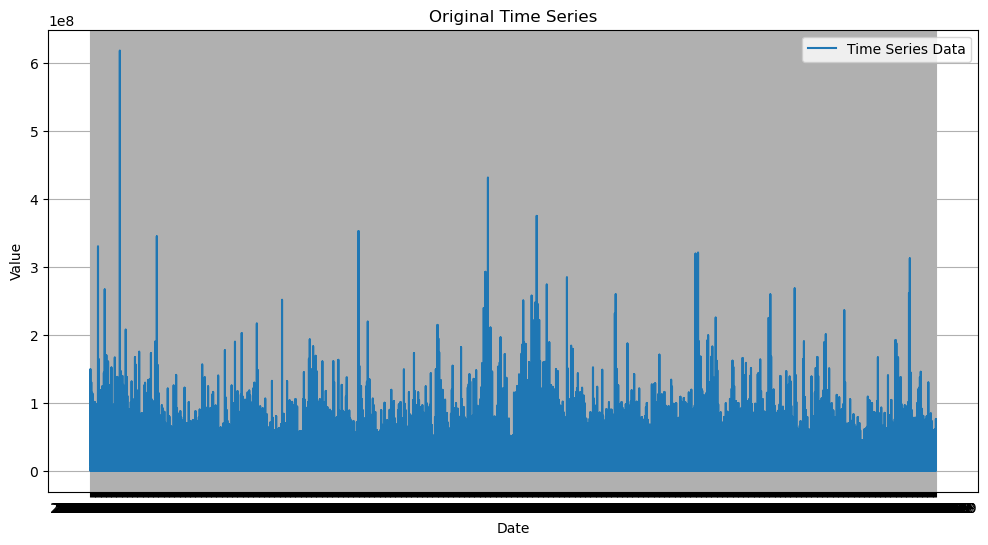

In [9]:
plt.figure(figsize=(12,6))
plt.plot(finalData['date'], finalData['volume'], label="Time Series Data")
plt.title("Original Time Series")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

C:\Users\Farida\AppData\Local\Temp\ipykernel_4036\73517625.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts['date'] = pd.to_datetime(ts['date'])


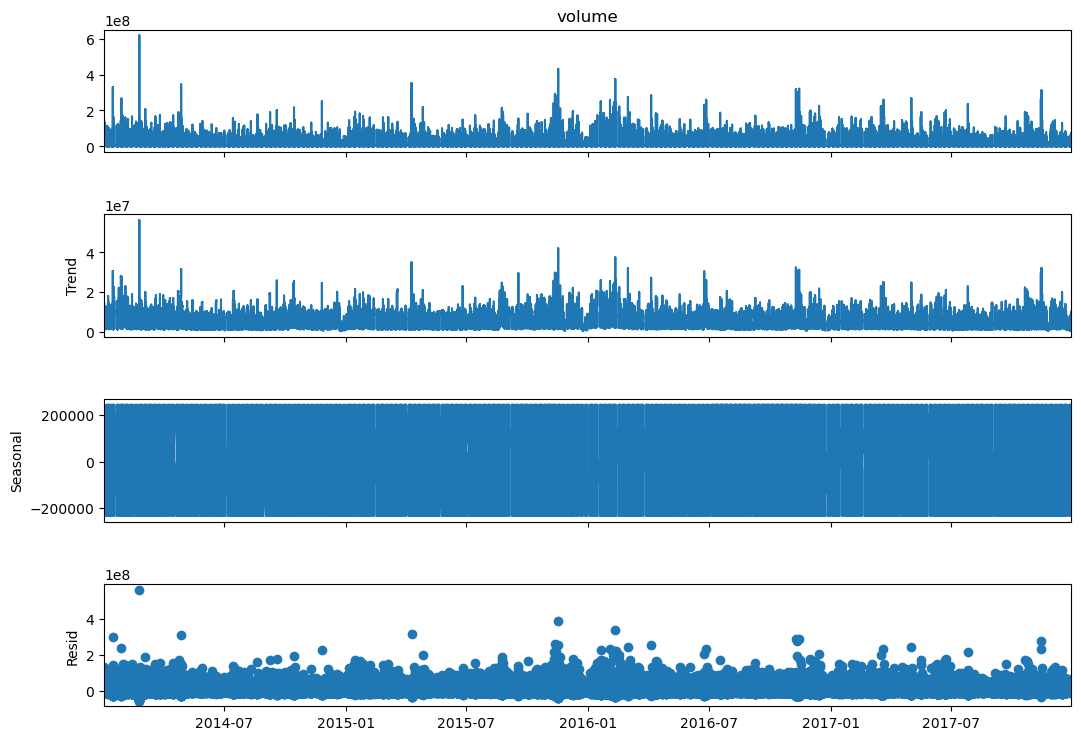

In [13]:
ts = finalData[['date', 'volume']]
ts['date'] = pd.to_datetime(ts['date'])
ts.set_index('date', inplace=True)
decompostion = seasonal_decompose(ts['volume'], model='additive', period=12)
fig = decompostion.plot()
fig.set_size_inches(12, 8)
plt.show()

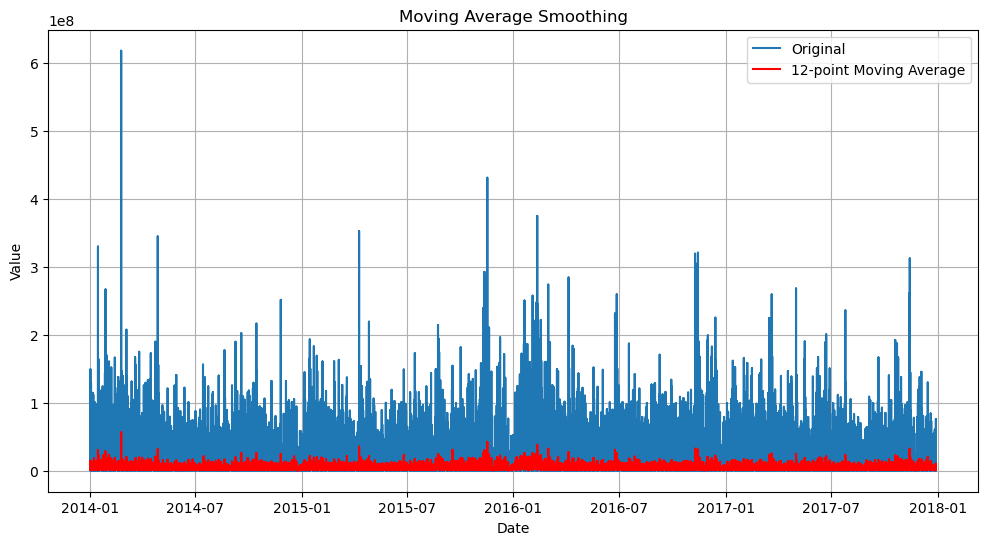

In [16]:
windowSize = 12
moving_avg = ts.rolling(window=windowSize).mean()

plt.figure(figsize=(12,6))
plt.plot(ts, label="Original")
plt.plot(moving_avg, color='red', label=f"{windowSize}-point Moving Average")
plt.title("Moving Average Smoothing")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()